# 08 · Baselines, other signals and the latent space of the affinity head (one tracking notebook)

This notebook keeps every open question in one place. Each section says what is asked, how it is measured, what it shows and what is still missing. It is self-filling: anything whose data does not exist yet prints `pending` and fills in when the notebook is re-run.

**Conventions.** Metrics are the project's (AP, EF@1%, BEDROC) on the common evaluation set (every compound ranked below 300; training compounds are the top-N of the Boltz-2 ranking). `head-FT` = the 5-seed head fine-tuning at N=300 unless stated. The latent analyses use the 384-dimensional features after `affinity_out_mlp` (the features the paper analyses; mean of the two ensemble modules) and the 128-dimensional pooled features before it, extracted from the same cached inputs by `pipeline_local/extract_latent.py` on a sample of each target: all 300 training compounds, all evaluation actives, 2,500 random evaluation inactives and the top-1% picks of both models. Estimates of whole-evaluation-set quantities use sample weights (random inactives are up-weighted; inactives that are in only because they are top picks get weight 0). Dimensionality reduction is **PCA only** (decision: no t-SNE or UMAP for now).

In [1]:

import sys, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
warnings.filterwarnings("ignore")
sys.path.insert(0, "/global/scratch/users/sergiomar10/boltzaff/pipeline_local")
import bft_common as bc, bft_signals as sg, bft_latent as lat
bc.style(); pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", lambda x: f"{x:.3f}")
TL = bc.done_targets("scores"); SH = bc.SHORT; BLK, OUR, THEIR, NEU = bc.BLK, bc.OUR, bc.THEIR, bc.NEU; GRN = "#1baf7a"
TCOL = dict(zip(bc.TARGETS, ["#2a78d6", "#eb6834", "#8e44ad", "#2a9d8f", "#c9a227", "#d62728", "#7f7f7f", "#17becf"]))
def each(fn, label="", targets=None):
    """run fn(t) for every finished target; collect DataFrames; report targets that are pending or fail"""
    out, skipped = [], []
    for t in (targets or TL):
        try:
            r = fn(t)
            if r is None: skipped.append(f"{SH[t]} (pending)")
            else: out.append(r)
        except Exception as e: skipped.append(f"{SH[t]} ({type(e).__name__}: {str(e)[:60]})")
    if skipped: print(f"{label}: not available for " + ", ".join(skipped))
    return pd.concat(out, ignore_index=True) if out and isinstance(out[0], pd.DataFrame) else out
def gmean(x): x = np.asarray(x, float); x = x[np.isfinite(x) & (x > 0)]; return float(np.exp(np.log(x).mean())) if len(x) else np.nan
def arms_done(t): return [a for a in ("noft", "ft300s0", "ft300s1") if lat.load_latent(t, a) is not None]


## Question tracker
Status is computed from the files that exist. 'n of 6' = finished targets with that analysis available.

In [2]:
def n_ok(check): return sum(1 for t in TL if check(t))
TR = [
 ("LightGBM from scratch vs warm-started from the Boltz-2 score vs head-FT", "Part 1", lambda t: (bc.AN / t / "lgbm_warmstart.csv").exists()),
 ("Both heads' probabilities and the affinity value as rankers", "Part 2a", lambda t: True),
 ("Do unwanted-substructure filters (PAINS / Brenk / NIH) explain part of the gain?", "Part 2b", lambda t: True),
 ("Scaffold-disjoint evaluation (cluster-aware)", "Part 2c", lambda t: True),
 ("Physicochemical properties: property baselines and what the picks look like", "Part 2d", lambda t: True),
 ("Potency tiers (dose-response value) of the actives that are found", "Part 2e", lambda t: True),
 ("Cross-target promiscuity", "Part 2f", lambda t: True),
 ("Pose confidence (ipTM / PDE) vs activity", "Part 2g", lambda t: t == "588689"),
 ("Pose-derived interaction labels (contacts, H-bonds, buried area; PLIP-like)", "Part 2h", lambda t: False),
 ("PCA of post-MLP features before vs after fine-tuning", "Part 3a", lambda t: len(arms_done(t)) >= 2),
 ("Linear probes on frozen features before vs after", "Part 3b", lambda t: len(arms_done(t)) >= 2),
 ("Direction (not only size) of the feature shift; shared activity direction?", "Part 3c", lambda t: len(arms_done(t)) >= 2),
 ("Latent coordinates vs interpretable descriptors", "Part 3d", lambda t: len(arms_done(t)) >= 2),
 ("Training actives vs evaluation actives in latent space (failure analysis)", "Part 3e", lambda t: len(arms_done(t)) >= 2),
 ("Applicability domain: latent distance to training actives vs Tanimoto", "Part 3f", lambda t: len(arms_done(t)) >= 2),
 ("Nearest-active baseline in latent space vs Morgan Tanimoto", "Part 3f", lambda t: len(arms_done(t)) >= 2),
]
T = pd.DataFrame([dict(question=q, section=s, status=("done" if n_ok(c) == len(TL) else f"{n_ok(c)} of {len(TL)} targets" if n_ok(c) else "pending")) for q, s, c in TR])
display(T.style.hide(axis="index"))
print("latent arms extracted per target:", {SH[t]: arms_done(t) for t in TL})
print("not covered here, for lack of data: 2650 and 588549 are not scored yet (588549 would be the failure-analysis target)")

question,section,status
LightGBM from scratch vs warm-started from the Boltz-2 score vs head-FT,Part 1,done
Both heads' probabilities and the affinity value as rankers,Part 2a,done
Do unwanted-substructure filters (PAINS / Brenk / NIH) explain part of the gain?,Part 2b,done
Scaffold-disjoint evaluation (cluster-aware),Part 2c,done
Physicochemical properties: property baselines and what the picks look like,Part 2d,done
Potency tiers (dose-response value) of the actives that are found,Part 2e,done
Cross-target promiscuity,Part 2f,done
Pose confidence (ipTM / PDE) vs activity,Part 2g,1 of 6 targets
"Pose-derived interaction labels (contacts, H-bonds, buried area; PLIP-like)",Part 2h,pending
PCA of post-MLP features before vs after fine-tuning,Part 3a,pending


latent arms extracted per target: {'588689': [], '504329': [], '743445': [], '485317': [], '2097': [], '493091': []}
not covered here, for lack of data: 2650 and 588549 are not scored yet (588549 would be the failure-analysis target)


## Part 1. Supervised baselines: from scratch, or starting from the Boltz-2 score
The paper's LightGBM baseline is trained from scratch on 40 / 100 / 300 labelled compounds and never sees Boltz-2's score, whereas head-FT starts from it (and DrugCLIP is already fine-tuned from a pretrained model). Arms (all with 5 seeds, same training compounds and same evaluation set as head-FT; the seeds only change LightGBM's row and column subsampling, the training set is fixed):
- `LGBM_ECFP_scratch`: ECFP only (the paper's baseline, 3-fold CV over a 27-setting grid).
- `LGBM_ECFP_residual`: boosting starts from the logit of the Boltz-2 score (`init_score`) and learns a correction from ECFP; the number of trees is chosen by CV and 0 trees (= the Boltz-2 score unchanged) is a candidate. This is the closest analogue of fine-tuning.
- `LGBM_ECFP_plus_score`: ECFP plus the Boltz-2 score as one more feature, from scratch.
- `NearestActive_Tanimoto`: rank by the highest ECFP4 Tanimoto to a training active (no learning).

Reference for the ratios is the dataset's shipped Boltz-2 score on the same evaluation compounds, which is what the baseline script can use for the training compounds as well. It is not identical to our own No-FT run (a table below compares them), so head-FT ratios here differ from the README's, which use our own No-FT. **Limit:** training compounds are all from the top of the Boltz-2 ranking, so their scores span a narrow range, and any correction learned from them has to extrapolate to the bulk of the library.

Geometric-mean AP ratio to the shipped Boltz-2 score over 6 targets (1 = no change):


n_train,40,100,300
method,,,
head-FT (Boltz-2),1.522,1.622,2.218
LGBM_ECFP_residual,1.060,1.289,1.882
NearestActive_Tanimoto,0.683,0.953,1.771
LGBM_ECFP_scratch,0.620,0.739,1.315
LGBM_ECFP_plus_score,0.662,0.790,1.181


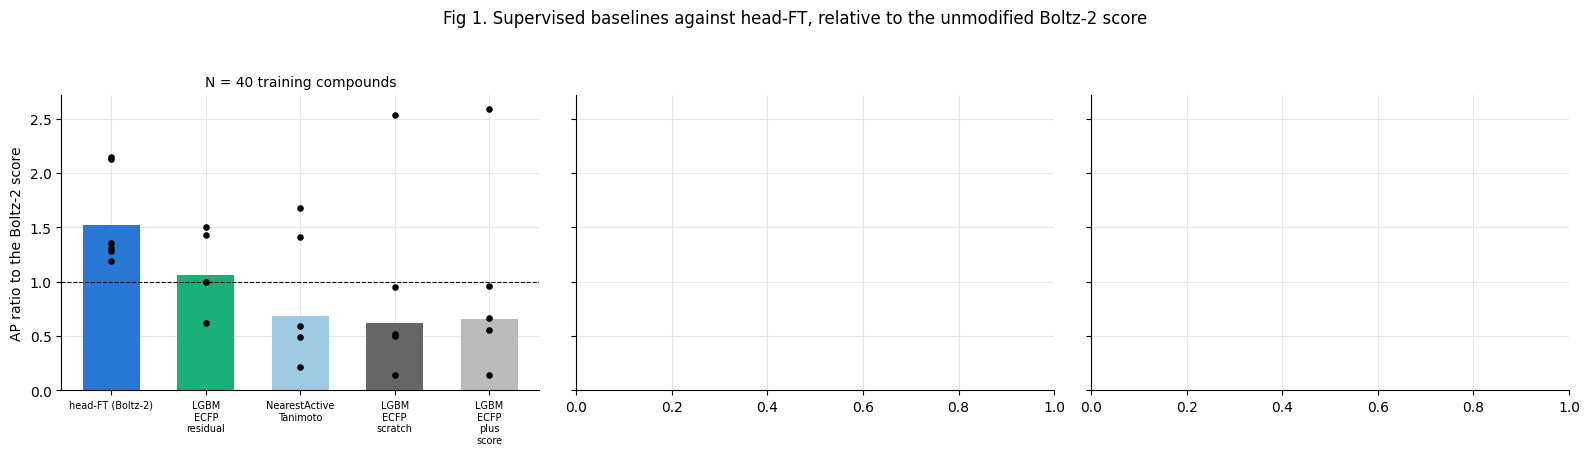

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

AP at N = 300 by target:


method,Boltz-2 score,head-FT (Boltz-2),LGBM_ECFP_residual,NearestActive_Tanimoto,LGBM_ECFP_scratch,LGBM_ECFP_plus_score
target,,,,,,
2097,0.076,0.226,0.282,0.303,0.202,0.195
485317,0.035,0.054,0.065,0.045,0.064,0.067
493091,0.057,0.095,0.091,0.089,0.052,0.046
504329,0.049,0.174,0.142,0.077,0.114,0.071
588689,0.095,0.207,0.087,0.166,0.043,0.038
743445,0.021,0.043,0.032,0.030,0.024,0.025


The shipped Boltz-2 score against our own No-FT run (different Pass-1/Pass-2 sampling) and the head-FT ratio relative to each:


,ap_shipped_boltz2_score,ap_our_own_NoFT,difference,headFT_over_shipped,headFT_over_our_NoFT
target,,,,,
588689,0.095,0.097,0.002,2.174,2.124
504329,0.049,0.051,0.001,3.519,3.424
743445,0.021,0.022,0.001,2.033,1.919
485317,0.035,0.039,0.004,1.549,1.395
2097,0.076,0.098,0.022,2.973,2.300
493091,0.057,0.059,0.001,1.663,1.625


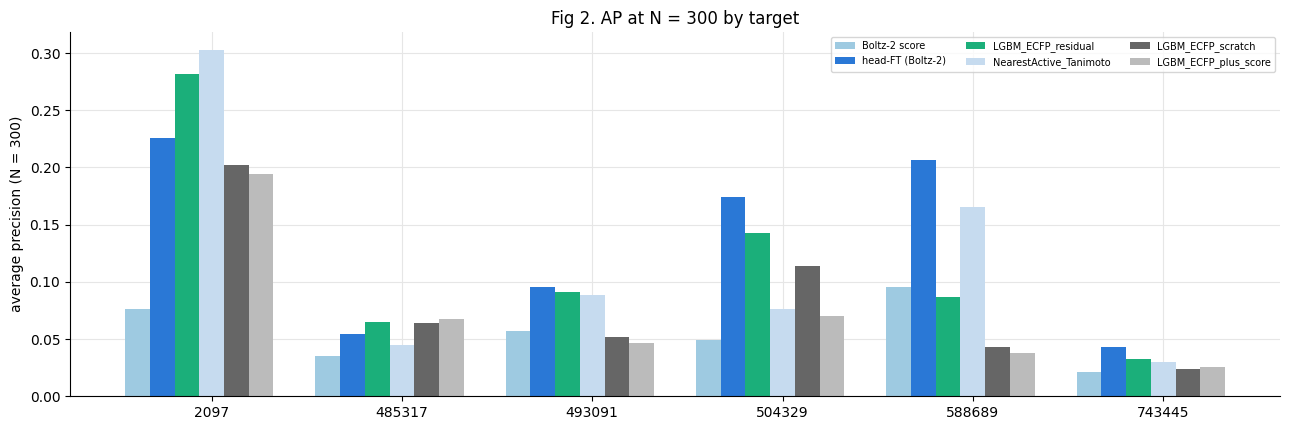

In [3]:
B = sg.baseline_table()
if B.empty: print("pending: run pipeline_local/lgbm_warmstart.py --target <t>")
else:
    ORDER = ["head-FT (Boltz-2)", "LGBM_ECFP_residual", "NearestActive_Tanimoto", "LGBM_ECFP_scratch", "LGBM_ECFP_plus_score"]
    G = B.pivot_table(index="method", columns="n_train", values="ratio", aggfunc=gmean).reindex(ORDER)
    print("Geometric-mean AP ratio to the shipped Boltz-2 score over", B.target.nunique(), "targets (1 = no change):"); display(G)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
    for ax, N in zip(axes, (40, 100, 300)):
        d = B[B.n_train == N]
        for i, m in enumerate(ORDER):
            v = d[d.method == m].ratio.values; ax.bar(i, gmean(v), 0.6, color=[OUR, GRN, "#9ecae1", NEU, "#bbbbbb"][i]); ax.scatter(np.full(len(v), i), v, s=14, color=BLK, zorder=3)
        ax.axhline(1, color=BLK, ls="--", lw=.8); ax.set_xticks(range(len(ORDER))); ax.set_xticklabels([o.replace("_", "\n") for o in ORDER], fontsize=7); ax.set_title(f"N = {N} training compounds", fontsize=10); axes[0].set_ylabel("AP ratio to the Boltz-2 score"); fig.suptitle("Fig 1. Supervised baselines against head-FT, relative to the unmodified Boltz-2 score"); plt.tight_layout(rect=[0, 0, 1, .94]); plt.show()
    P = B[B.n_train == 300].pivot(index="target", columns="method", values="ap")[ORDER]; P.insert(0, "Boltz-2 score", B[B.n_train == 300].groupby("target").ap_noft.first())
    print("AP at N = 300 by target:"); display(P)
    rows = []
    for t in TL:
        p_ = bc.per_seed(t); own = p_[p_.arm == "base"].ap.iloc[0]; shipped = B[B.target == SH[t]].ap_noft.iloc[0]; ft_ = p_[(p_.arm == "headft") & (p_.n_train == 300)].ap.mean()
        rows.append(dict(target=SH[t], ap_shipped_boltz2_score=shipped, ap_our_own_NoFT=own, difference=own - shipped, headFT_over_shipped=ft_ / shipped, headFT_over_our_NoFT=ft_ / own))
    print("The shipped Boltz-2 score against our own No-FT run (different Pass-1/Pass-2 sampling) and the head-FT ratio relative to each:"); display(pd.DataFrame(rows).set_index("target").round(3))
    fig, ax = plt.subplots(figsize=(13, 4.4)); cols = ["Boltz-2 score"] + ORDER; w = .13; x = np.arange(len(P))
    for j, c in enumerate(cols): ax.bar(x + (j - 3) * w, P[c].values, w, color=["#9ecae1", OUR, GRN, "#c6dbef", NEU, "#bbbbbb"][j] if j < 6 else None, label=c)
    ax.set_xticks(x); ax.set_xticklabels(P.index); ax.set_ylim(0, None); ax.set_ylabel("average precision (N = 300)"); ax.legend(fontsize=7, ncol=3); ax.set_title("Fig 2. AP at N = 300 by target"); plt.tight_layout(); plt.show()

In [4]:
if not B.empty:
    G3 = G[300]; print("Computed readout (N = 300):")
    print(f"  head-FT geometric-mean ratio {G3['head-FT (Boltz-2)']:.2f}; warm-started LightGBM {G3['LGBM_ECFP_residual']:.2f}; nearest-active Tanimoto {G3['NearestActive_Tanimoto']:.2f}; LightGBM from scratch {G3['LGBM_ECFP_scratch']:.2f}; ECFP + score feature {G3['LGBM_ECFP_plus_score']:.2f}.")
    wins = B[B.n_train == 300].pivot(index="target", columns="method", values="ap")
    for m in ("LGBM_ECFP_residual", "NearestActive_Tanimoto", "LGBM_ECFP_scratch"):
        w_ = [SH_ for SH_ in wins.index if wins.loc[SH_, m] > wins.loc[SH_, "head-FT (Boltz-2)"]]
        print(f"  {m} has a higher seed-mean AP than head-FT on: {', '.join(w_) if w_ else 'no target'}")
    print("  Ratios at N = 40 and N = 100:", {int(n): {k: round(float(v), 2) for k, v in G[n].items()} for n in (40, 100)})
    print("Caveats: one configuration per arm; no confidence intervals here (seed-to-seed spread is in `ap_sd` of the table above); head-FT and the baselines see the same training compounds.")

Computed readout (N = 300):
  head-FT geometric-mean ratio 2.22; warm-started LightGBM 1.88; nearest-active Tanimoto 1.77; LightGBM from scratch 1.31; ECFP + score feature 1.18.
  LGBM_ECFP_residual has a higher seed-mean AP than head-FT on: 2097, 485317
  NearestActive_Tanimoto has a higher seed-mean AP than head-FT on: 2097
  LGBM_ECFP_scratch has a higher seed-mean AP than head-FT on: 485317
  Ratios at N = 40 and N = 100: {40: {'head-FT (Boltz-2)': 1.52, 'LGBM_ECFP_residual': 1.06, 'NearestActive_Tanimoto': 0.68, 'LGBM_ECFP_scratch': 0.62, 'LGBM_ECFP_plus_score': 0.66}, 100: {'head-FT (Boltz-2)': 1.62, 'LGBM_ECFP_residual': 1.29, 'NearestActive_Tanimoto': 0.95, 'LGBM_ECFP_scratch': 0.74, 'LGBM_ECFP_plus_score': 0.79}}
Caveats: one configuration per arm; no confidence intervals here (seed-to-seed spread is in `ap_sd` of the table above); head-FT and the baselines see the same training compounds.


## Part 2. Other signals that can be derived from what we already have

### 2a. The two heads and the affinity value
The binary output is the mean of two ensemble heads; each module also outputs an affinity value (log IC50-like; lower = tighter binding, so it is negated for ranking). Head fine-tuning trains the binary output only, so the value output is a check on how much activity signal sits outside the trained path.

In [5]:
H = each(sg.heads_table, "heads")
if len(H):
    P = H.pivot_table(index="output", columns=["arm", "target"], values="ap"); display(P.round(3))
    M = H[H.output != "Spearman(value, probability)"].groupby(["arm", "output"]).ap.mean().unstack(0).round(3); print("Mean AP over targets:"); display(M)
    R = H[H.output == "Spearman(value, probability)"].pivot(index="target", columns="arm", values="ap"); print("Spearman correlation between the affinity value and the probability, by target:"); display(R)

arm                              No-FT                                    head-FT N=300                                   
target                            2097 485317 493091 504329 588689 743445          2097 485317 493091 504329 588689 743445
output                                                                                                                    
Spearman(value, probability)    -0.040 -0.257 -0.272 -0.398 -0.301 -0.302         0.139  0.177 -0.324 -0.096 -0.510 -0.309
affinity value (negated)         0.024  0.019  0.019  0.010  0.024  0.004         0.014  0.017  0.022  0.011  0.038  0.005
affinity value head 1 (negated)  0.016  0.020  0.017  0.009  0.015  0.004         0.014  0.020  0.017  0.009  0.017  0.004
affinity value head 2 (negated)  0.025  0.017  0.019  0.011  0.022  0.005         0.012  0.016  0.026  0.012  0.037  0.004
ensemble probability             0.098  0.039  0.059  0.051  0.097  0.022         0.226  0.054  0.095  0.174  0.207  0.043
head 1 probability               0.061  0.034  0.058  0.060  0.066  0.034         0.149  0.058  0.080  0.197  0.154  0.049
head 2 probability               0.092  0.037  0.033  0.025  0.050  0.007         0.180  0.030  0.070  0.029  0.093  0.020

Mean AP over targets:


arm,No-FT,head-FT N=300
output,,
affinity value (negated),0.017,0.018
affinity value head 1 (negated),0.013,0.014
affinity value head 2 (negated),0.017,0.018
ensemble probability,0.061,0.133
head 1 probability,0.052,0.114
head 2 probability,0.041,0.070


Spearman correlation between the affinity value and the probability, by target:


arm,No-FT,head-FT N=300
target,,
2097,-0.040,0.139
485317,-0.257,0.177
493091,-0.272,-0.324
504329,-0.398,-0.096
588689,-0.301,-0.510
743445,-0.302,-0.309


### 2b. Unwanted-substructure filters (PAINS, Brenk, NIH)
The dataset has been PAINS-filtered upstream: its `PAINS` column is False for every compound and RDKit's PAINS catalog also flags none, so a PAINS test is empty by construction. Brenk (unwanted / reactive groups) and NIH (reactive or promiscuous motifs) flag compounds, so they serve as a check on whether the gain rests on assay-artifact-like chemistry.

In [6]:
F = each(sg.pains_table, "filters")
if len(F):
    pv = F[F.catalog == "BRENK"].pivot(index="target", columns="arm", values=["library_flagged", "actives_flagged", "top1pct_flagged", "ap_all", "ap_unflagged_only"]); print("Brenk flags (shares) and AP with and without flagged compounds:"); display(pv.round(3))
    rr = F[F.catalog == "BRENK"].pivot(index="target", columns="arm", values="ap_all"); ru = F[F.catalog == "BRENK"].pivot(index="target", columns="arm", values="ap_unflagged_only")
    print("head-FT / No-FT AP ratio, all compounds vs only compounds Brenk does not flag:"); display(pd.DataFrame({"all": rr["head-FT N=300"] / rr["No-FT"], "unflagged only": ru["head-FT N=300"] / ru["No-FT"]}))
    n_ = F[F.catalog == "NIH"].pivot(index="target", columns="arm", values="ap_unflagged_only"); print("NIH: head-FT / No-FT AP ratio on unflagged compounds:"); display((n_["head-FT N=300"] / n_["No-FT"]).to_frame("ratio"))

Brenk flags (shares) and AP with and without flagged compounds:


library_flagged               actives_flagged               top1pct_flagged               ap_all               ap_unflagged_only              
arm              No-FT head-FT N=300           No-FT head-FT N=300           No-FT head-FT N=300  No-FT head-FT N=300             No-FT head-FT N=300
target                                                                                                                                               
2097             0.374         0.374           0.547         0.547           0.554         0.621  0.098         0.231             0.122         0.133
485317           0.364         0.364           0.468         0.468           0.610         0.571  0.039         0.056             0.029         0.037
493091           0.367         0.367           0.516         0.516           0.614         0.706  0.059         0.100             0.049         0.052
504329           0.368         0.368           0.589         0.589           0.573         0.650  0.051         0.193             0.051         0.229
588689           0.364         0.364           0.629         0.629           0.668         0.640  0.097         0.215             0.085         0.161
743445           0.361         0.361           0.634         0.634           0.628         0.475  0.022         0.043             0.011         0.042

head-FT / No-FT AP ratio, all compounds vs only compounds Brenk does not flag:


,all,unflagged only
target,,
2097,2.355,1.091
485317,1.436,1.313
493091,1.715,1.073
504329,3.793,4.442
588689,2.209,1.908
743445,1.949,3.949


NIH: head-FT / No-FT AP ratio on unflagged compounds:


,ratio
target,
2097,2.395
485317,1.408
493091,1.665
504329,4.141
588689,2.349
743445,1.935


### 2c. Scaffold-disjoint (cluster-aware) evaluation
AP of No-FT and head-FT after removing evaluation compounds that share a Bemis-Murcko scaffold (exact, or generic = atoms and bonds reduced to carbon and single bonds) with any of the 300 training compounds. If the gain were scaffold memorisation the ratio would fall to 1.

In [7]:
Sc = each(sg.scaffold_table, "scaffolds")
if len(Sc):
    display(Sc.pivot(index="target", columns="subset", values="ratio").round(2)); print("Actives and compounds left in each subset:"); display(Sc.pivot(index="target", columns="subset", values="actives"))

subset,all evaluation compounds,scaffold not in training (exact),scaffold not in training (generic)
target,,,
2097,2.350,2.170,1.200
485317,1.440,1.390,1.340
493091,1.720,1.570,1.520
504329,3.790,3.710,3.410
588689,2.210,1.920,1.910
743445,1.950,2.400,2.710


Actives and compounds left in each subset:


subset,all evaluation compounds,scaffold not in training (exact),scaffold not in training (generic)
target,,,
2097,415,338,266
485317,953,900,712
493091,739,704,662
504329,438,423,379
588689,396,319,285
743445,134,120,97


### 2d. Physicochemical properties
What the models pick compared with what is active: AUROC of each property alone (a property baseline) and the median property of the top-1% picks of No-FT and head-FT against the library and the actives. Size effects matter because the paper excludes ligands above 60 heavy atoms.

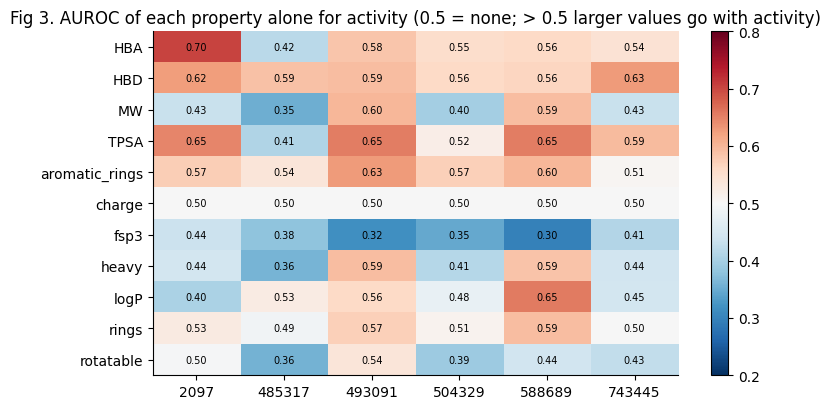

MW: median of library / actives / top 1% No-FT / top 1% head-FT


,median_library,median_actives,median_top1_noft,median_top1_ft
target,,,,
588689,360.370,392.320,350.120,394.390
504329,358.370,329.360,438.550,318.170
743445,358.380,333.300,310.360,366.460
485317,356.450,316.360,315.760,276.290
2097,355.430,337.410,303.540,299.840
493091,358.420,383.910,366.400,376.410


heavy: median of library / actives / top 1% No-FT / top 1% head-FT


,median_library,median_actives,median_top1_noft,median_top1_ft
target,,,,
588689,25.000,27.000,24.000,26.000
504329,25.000,23.000,31.000,22.000
743445,25.000,24.000,22.000,26.000
485317,25.000,22.000,22.000,18.000
2097,25.000,23.000,21.000,21.000
493091,25.000,27.000,25.000,27.000


logP: median of library / actives / top 1% No-FT / top 1% head-FT


,median_library,median_actives,median_top1_noft,median_top1_ft
target,,,,
588689,2.980,3.740,3.240,3.510
504329,2.970,2.940,4.030,2.740
743445,2.970,2.700,3.320,3.690
485317,2.940,3.070,3.080,2.920
2097,2.980,2.570,2.800,2.570
493091,2.970,3.200,3.600,3.690


largest ligand (heavy atoms) per target: {'588689': 92, '504329': 96, '743445': 68, '485317': 100, '2097': 95, '493091': 93}


The paper is said to exclude ligands above 60 heavy atoms; these libraries contain them. Effect of dropping them on the head-FT / No-FT AP ratio:


,share_above_60_heavy_atoms,actives_above_60,ratio_all,ratio_only_up_to_60
target,,,,
588689,0.000,0,2.209,2.223
504329,0.000,1,3.793,3.776
743445,0.000,0,1.949,1.949
485317,0.000,0,1.436,1.434
2097,0.000,0,2.355,2.355
493091,0.000,1,1.715,1.709


In [8]:
Pt = each(sg.property_table, "properties")
if len(Pt):
    A = Pt.pivot(index="property", columns="target", values="auroc_alone"); fig, ax = plt.subplots(figsize=(8, 4.2)); im = ax.imshow(A.values, cmap="RdBu_r", vmin=.2, vmax=.8, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(A.shape[1])); ax.set_xticklabels(A.columns); ax.set_yticks(range(A.shape[0])); ax.set_yticklabels(A.index)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]): ax.text(j, i, f"{A.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title("Fig 3. AUROC of each property alone for activity (0.5 = none; > 0.5 larger values go with activity)"); plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
    for p in ("MW", "heavy", "logP"):
        print(f"{p}: median of library / actives / top 1% No-FT / top 1% head-FT"); display(Pt[Pt.property == p].set_index("target")[["median_library", "median_actives", "median_top1_noft", "median_top1_ft"]].round(2))
    heavy = [sg.physchem(t).heavy.max() for t in TL]; print("largest ligand (heavy atoms) per target:", dict(zip([SH[t] for t in TL], [int(h) for h in heavy])))
    rows = []
    for t in TL:
        S_ = bc.scores(t); P_ = sg.physchem(t).set_index("id").reindex(S_.id); big = (P_.heavy.values > 60); y_ = S_.label.values; ft_ = bc.ft_mean(S_, 300).values; ok = ~big
        rows.append(dict(target=SH[t], share_above_60_heavy_atoms=big.mean(), actives_above_60=int(y_[big].sum()), ratio_all=sg._m(y_, ft_)["ap"] / sg._m(y_, S_.noft_p.values)["ap"], ratio_only_up_to_60=sg._m(y_[ok], ft_[ok])["ap"] / sg._m(y_[ok], S_.noft_p.values[ok])["ap"]))
    print("The paper is said to exclude ligands above 60 heavy atoms; these libraries contain them. Effect of dropping them on the head-FT / No-FT AP ratio:"); display(pd.DataFrame(rows).set_index("target").round(3))

### 2e. Potency tiers
Share of the evaluation actives found in the top 1%, split into thirds by the dose-response value `DR` of the active (assumed larger = more potent; not confirmed against the dataset documentation). Shows whether fine-tuning finds stronger or weaker actives.

found_noft                                            found_ft                                
tier   highest third of DR lowest third of DR middle third highest third of DR lowest third of DR middle third
target                                                                                                        
2097                 0.225              0.101        0.254               0.399              0.129        0.297
485317               0.053              0.041        0.028               0.079              0.050        0.073
493091               0.106              0.045        0.081               0.211              0.061        0.110
504329               0.103              0.062        0.130               0.466              0.075        0.404
588689               0.197              0.159        0.152               0.386              0.242        0.318
743445               0.244              0.174        0.070               0.178              0.087        0.116

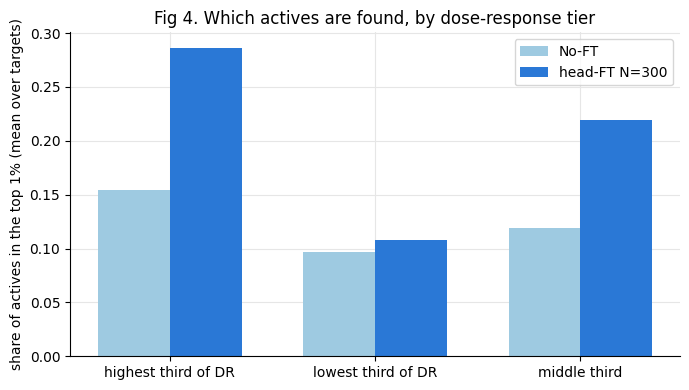

In [9]:
Tt = each(sg.tier_table, "tiers")
if len(Tt):
    d = Tt.pivot(index="target", columns="tier", values=["found_noft", "found_ft"]); display(d.round(3))
    x = Tt.groupby("tier")[["found_noft", "found_ft"]].mean(); fig, ax = plt.subplots(figsize=(7, 4)); w = .35
    ax.bar(np.arange(3) - w / 2, x.found_noft, w, color="#9ecae1", label="No-FT"); ax.bar(np.arange(3) + w / 2, x.found_ft, w, color=OUR, label="head-FT N=300"); ax.set_xticks(range(3)); ax.set_xticklabels(x.index)
    ax.set_ylabel("share of actives in the top 1% (mean over targets)"); ax.set_ylim(0, None); ax.legend(); ax.set_title("Fig 4. Which actives are found, by dose-response tier"); plt.tight_layout(); plt.show()

### 2f. Cross-target promiscuity
Compounds appear in several of the eight assay libraries (by PubChem CID). A compound that is active in other assays but inactive here is a 'frequent hitter' candidate; if the score tracks general hit-likeness, those compounds should score high even where they are inactive.

In [10]:
L, n_in, n_act = sg.crosstarget(); print("compounds present in >= 2 libraries:", int((n_in >= 2).sum()), "; active in >= 2 targets:", int((n_act >= 2).sum()), "; active in >= 3:", int((n_act >= 3).sum()))
Pr = each(sg.promiscuity_table, "promiscuity")
if len(Pr):
    display(Pr.pivot(index="target", columns="group", values="median_percentile_noft").round(2).rename_axis("median percentile under No-FT"))
    display(Pr.pivot(index="target", columns="group", values="median_percentile_ft").round(2).rename_axis("median percentile under head-FT"))
    display(Pr.pivot(index="target", columns="group", values="n"))

compounds present in >= 2 libraries: 115193 ; active in >= 2 targets: 98 ; active in >= 3: 3


group,active here and in >=1 other target,active here only,inactive everywhere,"inactive here, active elsewhere"
median percentile under No-FT,,,,
2097,0.940,0.940,0.490,0.810
485317,0.870,0.690,0.490,0.750
493091,0.960,0.850,0.490,0.760
504329,0.740,0.910,0.490,0.730
588689,0.970,0.950,0.490,0.820
743445,0.960,0.920,0.500,0.790


group,active here and in >=1 other target,active here only,inactive everywhere,"inactive here, active elsewhere"
median percentile under head-FT,,,,
2097,0.970,0.930,0.490,0.760
485317,0.840,0.760,0.490,0.680
493091,0.970,0.870,0.490,0.660
504329,0.820,0.940,0.490,0.740
588689,0.980,0.970,0.490,0.720
743445,0.950,0.850,0.500,0.700


group,active here and in >=1 other target,active here only,inactive everywhere,"inactive here, active elsewhere"
target,,,,
2097,7,408,48672,500
485317,24,929,48312,411
493091,24,715,48450,496
504329,15,423,48700,535
588689,30,366,48730,559
743445,22,112,49025,536


### 2g. Pose confidence vs activity (588689, where per-compound Boltz-2 confidence exists)
AUROC of ligand ipTM and PDE for activity, and how many actives have a doubtful pose (ligand ipTM below 0.7) and still rank high.

In [11]:
from sklearn.metrics import roc_auc_score
q = pd.read_csv(bc.RUNS / "588689/qc.csv"); res = pd.read_csv(bc.ROOT / "data/588689_results.csv").set_index("CID"); q["pct"] = q.CID.map(res.affinity_probability_binary.rank(pct=True))
rows = [dict(measure=c, actives_median=q[q.Active == 1][c].median(), inactives_median=q[q.Active == 0][c].median(), auroc_for_activity=roc_auc_score(q.Active, s * q[c])) for c, s in (("ligand_iptm", 1), ("complex_pde", -1), ("complex_plddt", 1))]
display(pd.DataFrame(rows)); lo = q[q.ligand_iptm < 0.7]; a = lo[lo.Active == 1]
print(f"588689: {len(q):,} poses with confidence, {int(q.Active.sum())} actives. ligand ipTM < 0.7: {len(lo)} poses ({100 * len(lo) / len(q):.1f}%), {len(a)} actives, of which {int((a.pct >= .95).sum())} are in the top 5% of the Boltz-2 score; active rate there {100 * lo.Active.mean():.1f}% vs {100 * q.Active.mean():.1f}% overall.")
print("No experimental ligand poses exist, so 'wrong pose' can only be judged by proxies (low confidence, off-pocket placement); see README finding 8 and notebook 05/07 for pocket placement.")

,measure,actives_median,inactives_median,auroc_for_activity
0,ligand_iptm,0.850,0.859,0.470
1,complex_pde,0.469,0.465,0.482
2,complex_plddt,0.910,0.919,0.380


588689: 21,061 poses with confidence, 238 actives. ligand ipTM < 0.7: 300 poses (1.4%), 10 actives, of which 7 are in the top 5% of the Boltz-2 score; active rate there 3.3% vs 1.1% overall.
No experimental ligand poses exist, so 'wrong pose' can only be judged by proxies (low confidence, off-pocket placement); see README finding 8 and notebook 05/07 for pocket placement.


### 2h. Pose-derived interaction labels (pending)
Contacts per residue, polar contacts as a hydrogen-bond proxy and buried fraction from the Boltz-2 poses (PLIP is not installed; a geometric proxy is the plan). Not computed yet. The per-residue contact matrices of the cliff-pair compounds already exist (`results/analysis/<t>/cliffs/contacts.npz`) and are used in notebooks 04 and 05.

## Part 3. The latent space of the affinity head
The head's forward pass pools the ligand-protein pair representation into a 128-dimensional vector (`g_raw`), passes it through a 2-layer MLP to 384 dimensions (`g`, the post-MLP features the paper analyses), and from `g` two small branches give the affinity value and the binary logit; two ensemble modules are averaged. Features are extracted for the same sample under No-FT and two head-FT seeds (N=300), so a difference between arms is a real change of the representation.

**Caveat on the paper's displacement-rank argument.** The reported correlation between the size of the feature shift and the rank change (about -0.6) is partly mechanical: compounds that start near the top have the most room to fall. The notebook reports both the raw and the partial correlation given the No-FT rank, and treats 'overestimated compounds get corrected' as a hypothesis.

### 3a. PCA of the post-MLP features, before and after
PCA is fitted on the No-FT features of the evaluation part of the sample (random inactives + actives) and both arms are projected on that basis, so a shift between the panels is a real shift. Grey = random evaluation inactives, orange = evaluation actives, light blue = training inactives, dark blue = training actives.

In [12]:
def pca_fig(targets):
    ok = [t for t in targets if len(arms_done(t)) >= 2 and "noft" in arms_done(t) and "ft300s0" in arms_done(t)]
    if not ok: print("pending: no target has the No-FT and a head-FT arm extracted yet"); return
    fig, axes = plt.subplots(len(ok), 2, figsize=(11, 4.3 * len(ok)), squeeze=False)
    for r, t in enumerate(ok):
        D, X = lat.aligned(t, ("noft", "ft300s0")); ev = (~D.is_train.values) & (D.w.values > 0); _, pn, evr = lat.pca_coords(X["noft"][ev], X["noft"], 10); _, pf2, _ = lat.pca_coords(X["noft"][ev], X["ft300s0"], 10)
        g = D.group.values; y = D.label.values
        for c, (P, name) in enumerate(((pn, "No-FT"), (pf2, "head-FT N=300 (seed 0)"))):
            ax = axes[r, c]; m = (g == "eval inactive") & D.random_inactive.values
            ax.scatter(P[m, 0], P[m, 1], s=4, c="#cccccc", alpha=.5, label="eval inactive (random)"); ax.scatter(P[(g == "train") & (y == 0), 0], P[(g == "train") & (y == 0), 1], s=7, c="#9ecae1", label="training inactive")
            ax.scatter(P[g == "eval active", 0], P[g == "eval active", 1], s=6, c=THEIR, alpha=.7, label="eval active"); ax.scatter(P[(g == "train") & (y == 1), 0], P[(g == "train") & (y == 1), 1], s=10, c=OUR, label="training active")
            ax.set_title(f"{SH[t]}: {name}", fontsize=9); ax.set_xlabel(f"PC1 ({100 * evr[0]:.0f}% of variance in No-FT features)"); ax.set_ylabel(f"PC2 ({100 * evr[1]:.0f}%)")
            if r == 0 and c == 0: ax.legend(fontsize=6, markerscale=2)
    fig.suptitle("Fig 5. PCA of the 384-dim post-MLP features, same basis for both arms"); plt.tight_layout(rect=[0, 0, 1, .98]); plt.show()
    rows = []
    for t in ok:
        D, X = lat.aligned(t, ("noft", "ft300s0")); ev = (~D.is_train.values) & (D.w.values > 0); y = D.label.values; w = D.w.values
        for arm in ("noft", "ft300s0"):
            _, P, evr = lat.pca_coords(X["noft"][ev], X[arm], 10); rows.append(dict(target=SH[t], arm=arm, var_PC1=evr[0], var_top10=evr.sum(), auroc_PC1=lat.wauc(y[ev], P[ev, 0], w[ev]), auroc_PC2=lat.wauc(y[ev], P[ev, 1], w[ev])))
    print("Share of variance in the first components (basis fitted on No-FT) and how well one component separates actives (AUROC, 0.5 = none; sign arbitrary):"); display(pd.DataFrame(rows))
pca_fig(TL)

pending: no target has the No-FT and a head-FT arm extracted yet


### 3b. Linear probes: re-weighting or re-mapping?
If a linear probe on the No-FT features already separates actives about as well as the fine-tuned head does, fine-tuning mostly re-weights what is already there; if the probe on the head-FT features is much better than on No-FT features, the representation itself was remapped. 'Trained on the 300' mimics the labelled data fine-tuning sees; the cross-validated probe on the evaluation sample is an upper bound for linear readability.

In [13]:
Pb = each(lambda t: lat.probe_table(t) if len(arms_done(t)) >= 2 else None, "probes")
if len(Pb):
    for m in ("ap", "auroc"):
        d = Pb.pivot_table(index=["target", "probe"], columns="arm", values=m); print(f"Weighted {m} on the evaluation sample:"); display(d.round(3))
    print("Reading: compare, within a target, 'trained on the 300' (No-FT features) with the same probe on head-FT features and with the head's own probability.")

probes: not available for 588689 (pending), 504329 (pending), 743445 (pending), 485317 (pending), 2097 (pending), 493091 (pending)


### 3c. Direction of the shift
For each compound d = f(head-FT) - f(No-FT). The paper reports only the size |d|. Here: `coherence` = |mean d| / mean |d| (1 = every compound moves the same way, near 0 = unrelated directions); mean cosine between the shifts of random pairs; the share of all shift energy in the single strongest direction; and whether the cosine of a compound's shift to the mean shift of the training actives (an 'activity direction') separates evaluation actives from inactives.

In [14]:
Dd = []
for t in TL:
    r = lat.displacement_table(t) if len(arms_done(t)) >= 2 else None
    if r is not None: Dd.append(r)
if Dd:
    tab = pd.DataFrame([r[0] for r in Dd]).set_index("target"); display(tab.round(3))
    fig, axes = plt.subplots(1, len(Dd), figsize=(3.4 * len(Dd), 3.4), squeeze=False)
    for ax, (row, d, D) in zip(axes[0], Dd):
        y = D.label.values; g = D.group.values; a_dir = d[(g == "train") & (y == 1)].mean(0); a_dir /= np.linalg.norm(a_dir); c = (d @ a_dir) / np.maximum(np.linalg.norm(d, axis=1), 1e-9); m = (~D.is_train.values) & (D.w.values > 0)
        ax.hist(c[m & (y == 0)], bins=40, range=(-1, 1), color="#bbbbbb", density=True, label="eval inactive"); ax.hist(c[m & (y == 1)], bins=40, range=(-1, 1), color=THEIR, alpha=.6, density=True, label="eval active")
        ax.set_title(row["target"], fontsize=9); ax.set_xlabel("cosine of the shift to the activity direction"); ax.set_ylabel("density")
    axes[0, 0].legend(fontsize=7); fig.suptitle("Fig 6. Is there a shared 'activity direction' in the feature shift?"); plt.tight_layout(rect=[0, 0, 1, .92]); plt.show()
else: print("pending: needs the No-FT and a head-FT arm of at least one target")

pending: needs the No-FT and a head-FT arm of at least one target


### 3d. Latent coordinates against interpretable descriptors
Spearman correlation between descriptors (MW, logP, heavy atoms, rings, TPSA, charge, ...) and the first principal components of the head-FT features and the size of the shift. A strong link to size or lipophilicity would say what the head learned to weight.

In [15]:
Ch = each(lambda t: lat.chemistry_table(t) if len(arms_done(t)) >= 2 else None, "chemistry")
if len(Ch):
    ts = list(Ch.target.unique()); cols = ["shift_norm"] + [f"PC{j} (head-FT)" for j in range(1, 6)]
    fig, axes = plt.subplots(1, len(ts), figsize=(3.6 * len(ts), 4.4), squeeze=False)
    for ax, t_ in zip(axes[0], ts):
        A = Ch[Ch.target == t_].set_index("property")[cols]; im = ax.imshow(A.values, cmap="RdBu_r", vmin=-.8, vmax=.8, aspect="auto"); ax.grid(False)
        ax.set_xticks(range(len(cols))); ax.set_xticklabels(["shift", "PC1", "PC2", "PC3", "PC4", "PC5"], fontsize=7); ax.set_yticks(range(len(A))); ax.set_yticklabels(A.index, fontsize=7); ax.set_title(t_, fontsize=9)
        for i in range(A.shape[0]):
            for j in range(A.shape[1]): ax.text(j, i, f"{A.values[i, j]:.1f}", ha="center", va="center", fontsize=6)
    fig.suptitle("Fig 7. Spearman correlation of descriptors with the head-FT features' principal components and with the size of the shift"); plt.tight_layout(rect=[0, 0, 1, .92]); plt.show()
else: print("pending")

chemistry: not available for 588689 (pending), 504329 (pending), 743445 (pending), 485317 (pending), 2097 (pending), 493091 (pending)
pending


### 3e. Direction versus the paper's size-only metric
Raw and partial correlation between the size of the feature shift and the rank change (head-FT percentile minus No-FT percentile over the whole evaluation set), with the partial correlation controlling for the No-FT rank. This is the paper's argument made explicit, together with the ceiling effect that makes the raw number look stronger than it is.

In [16]:
if Dd:
    d2 = pd.DataFrame([{k: r[0][k] for k in ("target", "rho_norm_vs_rank_change", "partial_rho_norm_vs_rank_change_given_noft_rank")} for r in Dd]).set_index("target"); display(d2.round(3))
    print("Reading: if the partial correlation is much closer to 0 than the raw one, most of the raw link is the 'high start, more room to fall' effect.")
else: print("pending")

pending


### 3f. Nearest-active baseline and applicability domain in latent space
(i) Ranking evaluation compounds by their highest cosine similarity to a training active, in the No-FT or head-FT feature space, compared with the Morgan Tanimoto nearest-active baseline and the head's own probability (weighted AP / AUROC on the sample). (ii) The top-1% picks of head-FT split into thirds by latent similarity, and by Tanimoto, to the nearest training active: do the picks nearer the training actives turn out active more often?

In [17]:
Nn = each(lambda t: lat.neighbour_table(t) if len(arms_done(t)) >= 2 else None, "neighbours")
if len(Nn):
    d = Nn.pivot(index="ranking", columns="target", values="ap"); print("Weighted AP on the evaluation sample:"); display(d.round(3)); print("Weighted AUROC:"); display(Nn.pivot(index="ranking", columns="target", values="auroc").round(3))
    fig, ax = plt.subplots(figsize=(12, 4.4)); order = list(d.index); w = .8 / len(order); x = np.arange(d.shape[1])
    for i, r_ in enumerate(order): ax.bar(x + (i - len(order) / 2) * w, d.loc[r_].values, w, label=r_)
    ax.set_xticks(x); ax.set_xticklabels(d.columns); ax.set_ylim(0, None); ax.set_ylabel("weighted average precision"); ax.legend(fontsize=6, ncol=2); ax.set_title("Fig 8. Nearest-active rankings: latent space against Morgan fingerprints"); plt.tight_layout(); plt.show()
Ap = each(lambda t: lat.applicability_table(t) if len(arms_done(t)) >= 2 else None, "applicability")
if len(Ap): display(Ap.pivot_table(index=["target", "measure"], columns="tercile", values="active_share").round(3)[["lowest third", "middle third", "highest third"]])

neighbours: not available for 588689 (pending), 504329 (pending), 743445 (pending), 485317 (pending), 2097 (pending), 493091 (pending)
applicability: not available for 588689 (pending), 504329 (pending), 743445 (pending), 485317 (pending), 2097 (pending), 493091 (pending)


### 3g. Training actives against evaluation actives (failure analysis)
For each target: how close, in latent space, evaluation actives are to the training actives compared with evaluation inactives (cosine similarity to the nearest training active; AUROC of that similarity for activity), and the number of training actives. Targets with few training actives (743445 has 10) are expected to generalise worst; 588549, the other weak target, is not scored yet.

In [18]:
rows = []
for t in TL:
    if len(arms_done(t)) < 2: continue
    D, X = lat.aligned(t, ("noft", "ft300s0")); y = D.label.values; ev = (~D.is_train.values) & (D.w.values > 0); ta = D.is_train.values & (y == 1)
    for arm in ("noft", "ft300s0"):
        F = X[arm] / np.linalg.norm(X[arm], axis=1, keepdims=True); s = (F @ F[ta].T).max(1)
        rows.append(dict(target=SH[t], arm=arm, training_actives=int(ta.sum()), median_sim_eval_active=float(np.median(s[ev & (y == 1)])), median_sim_eval_inactive=float(np.median(s[ev & (y == 0)])), auroc_of_similarity=lat.wauc(y[ev], s[ev], D.w.values[ev])))
if rows: display(pd.DataFrame(rows).set_index(["target", "arm"]).round(3))
else: print("pending")

pending


## Conclusions (computed from the results above)
Every statement is generated from the tables; sections whose data is missing say so and make no claim.

In [19]:
print("1. Baselines (N = 300, geometric-mean AP ratio to the Boltz-2 score):")
if not B.empty: print("   " + "; ".join(f"{m} {G[300][m]:.2f}" for m in ORDER))
else: print("   pending")
print("2. Other signals:")
if len(H): print(f"   affinity-value output as a ranker: mean AP {M.loc['affinity value (negated)', 'No-FT']:.3f} (No-FT) and {M.loc['affinity value (negated)', 'head-FT N=300']:.3f} (head-FT) against {M.loc['ensemble probability', 'No-FT']:.3f} and {M.loc['ensemble probability', 'head-FT N=300']:.3f} for the probability")
if len(F):
    b = F[F.catalog == "BRENK"].pivot(index="target", columns="arm", values="ap_all"); u = F[F.catalog == "BRENK"].pivot(index="target", columns="arm", values="ap_unflagged_only")
    print(f"   Brenk: head-FT / No-FT AP ratio falls from {gmean(b['head-FT N=300'] / b['No-FT']):.2f} on all compounds to {gmean(u['head-FT N=300'] / u['No-FT']):.2f} on compounds Brenk does not flag (geometric mean over targets)")
if len(Sc): print("   scaffold-disjoint ratio (exact scaffolds): " + ", ".join(f"{r.target} {r.ratio:.2f}" for r in Sc[Sc.subset == 'scaffold not in training (exact)'].itertuples()))
print("3. Latent space:")
done_t = [SH[t] for t in TL if len(arms_done(t)) >= 2]
print("   targets with extracted features:", done_t if done_t else "none yet (extraction jobs pending)")
if len(Pb):
    pp = Pb.pivot_table(index="target", columns=["probe", "arm"], values="ap"); print("   probes (weighted AP): see the table in 3b")
if Dd: print("   coherence of the shift: " + ", ".join(f"{r[0]['target']} {r[0]['coherence']:.2f}" for r in Dd) + " (1 = all compounds move the same way)")
print("Still open: pose-derived interaction labels (2h), 588549 failure analysis (needs scoring), t-SNE / UMAP (deliberately not done).")

1. Baselines (N = 300, geometric-mean AP ratio to the Boltz-2 score):
   head-FT (Boltz-2) 2.22; LGBM_ECFP_residual 1.88; NearestActive_Tanimoto 1.77; LGBM_ECFP_scratch 1.31; LGBM_ECFP_plus_score 1.18
2. Other signals:
   affinity-value output as a ranker: mean AP 0.017 (No-FT) and 0.018 (head-FT) against 0.061 and 0.133 for the probability
   Brenk: head-FT / No-FT AP ratio falls from 2.13 on all compounds to 1.93 on compounds Brenk does not flag (geometric mean over targets)
   scaffold-disjoint ratio (exact scaffolds): 588689 1.92, 504329 3.71, 743445 2.40, 485317 1.39, 2097 2.17, 493091 1.57
3. Latent space:
   targets with extracted features: none yet (extraction jobs pending)
Still open: pose-derived interaction labels (2h), 588549 failure analysis (needs scoring), t-SNE / UMAP (deliberately not done).
